# Data Exploration for Kaggle Housing Price Prediction

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

from pandas.api.types import CategoricalDtype

from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import mutual_info_regression

# set global theme and disable frames
sns.set_theme(style = 'white',
              rc={'legend.frameon': False},
              )
sns.set_style('ticks', {'xtick.major.size' : 8,
                        'ytick.major.size' : 8,
                        'xtick.bottom'     : True,
                        'ytick.left'       : True,
                        })

In [ ]:
# load the Kaggle train dataset
path_train = './input/train.csv.gz'
train      = pd.read_csv(path_train, compression='gzip', index_col='Id')

print(f'Shape of train_full dataset: {train.shape}')

Shape of train_full dataset: (1460, 80)


## Address Missing Data

In [ ]:
# look for columns with a lot of missing data
missing_count = train.isnull().sum().sort_values(ascending=False)
missing_pct   = ((train.isnull().sum() / train.isnull().count()).sort_values(ascending=False) * 100).astype(int).astype(str) + '%'
missing_data  = pd.concat([missing_count, missing_pct], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
PoolQC,1453,99%
MiscFeature,1406,96%
Alley,1369,93%
Fence,1179,80%
MasVnrType,872,59%
FireplaceQu,690,47%
LotFrontage,259,17%
GarageQual,81,5%
GarageType,81,5%
GarageFinish,81,5%


In [ ]:
# some columns here are nan for no feature so we can encode that instead of keeping values nan
train['PoolQC']        = train['PoolQC'].fillna('NA')
train['MiscFeature']   = train['MiscFeature'].fillna('NA')
train['Alley']         = train['Alley'].fillna('NA')
train['Fence']         = train['Fence'].fillna('NA')
train['MasVnrType']    = train['MasVnrType'].fillna('NA')
train['FireplaceQu']   = train['FireplaceQu'].fillna('NA')
train['GarageQual']    = train['GarageQual'].fillna('NA')
train['GarageFinish']  = train['GarageFinish'].fillna('NA')
train['GarageType']    = train['GarageType'].fillna('NA')
train['GarageCond']    = train['GarageCond'].fillna('NA')
train['BsmtFinType2']  = train['BsmtFinType2'].fillna('NA')
train['BsmtExposure']  = train['BsmtExposure'].fillna('NA')
train['BsmtCond']      = train['BsmtCond'].fillna('NA')
train['BsmtQual']      = train['BsmtQual'].fillna('NA')
train['BsmtFinType1']  = train['BsmtFinType1'].fillna('NA')

# no definition for nan in Electrical, only 1 missing so impute with mode
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])

# check which columns are remaining
print(f'Remaining NaN values:\n{train.isnull().sum().sort_values(ascending=False).head()}')

Remaining NaN values:
LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
MSSubClass       0
Street           0
dtype: int64


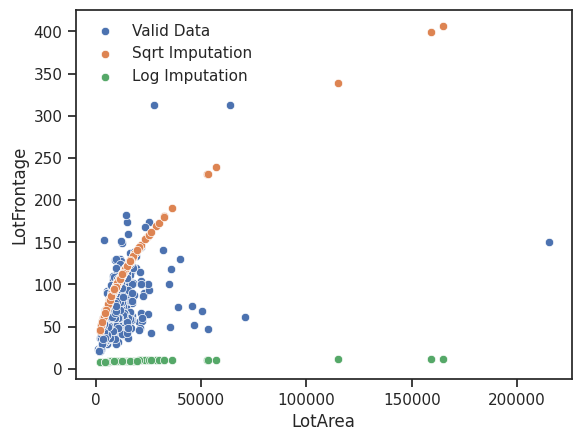

In [ ]:
# figure out what to do with LotFrontage

# guess how to impute nans by filling with a transformation of LotArea
train['RootArea'] = np.sqrt(train['LotArea'])
train['LogArea']  = np.log(train['LotArea'])

fig, ax = plt.subplots()

sns.scatterplot(data=train, x='LotArea', y='LotFrontage', label='Valid Data')
sns.scatterplot(data=train[train['LotFrontage'].isna()], x='LotArea', y='RootArea', label='Sqrt Imputation')
sns.scatterplot(data=train[train['LotFrontage'].isna()], x='LotArea', y='LogArea', label='Log Imputation')

ax.legend()
plt.show()

# filling missing LotFrontage with the root of LotArea seems to agree
# reasonably well with the bulk of the data so it's probalby good
# enough for now
train['LotFrontage'] = train['LotFrontage'].fillna(train['RootArea'])

train = train.drop(columns=['RootArea', 'LogArea'])

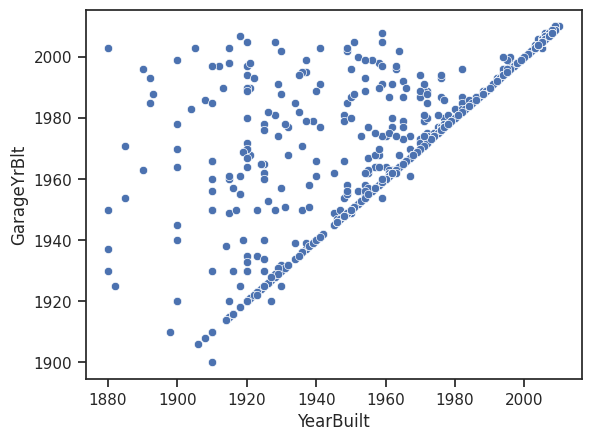

In [ ]:
# figure out what to do wtih GarageYrBlt

sns.scatterplot(train, x='YearBuilt', y='GarageYrBlt')
plt.show()

# impute missing values with YearBuilt so missing values are roughly
# in line with rest of the data
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(train['YearBuilt'])

# looks like some data has the garage built before the house?
# just set these values to YearBuilt
train.loc[train['GarageYrBlt'] < train['YearBuilt'], 'GarageYrBlt'] = train['YearBuilt']

      MasVnrArea MasVnrType
Id                         
235          NaN         NA
530          NaN         NA
651          NaN         NA
937          NaN         NA
974          NaN         NA
978          NaN         NA
1244         NaN         NA
1279         NaN         NA


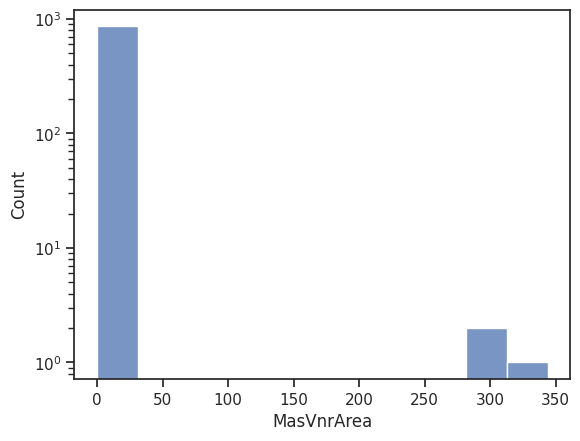

In [ ]:
# figure out what to do with MasVnrArea

# MasVnrArea is only nan when MasVnrType is NA
print(train[train['MasVnrArea'].isna()][['MasVnrArea', 'MasVnrType']])

# most MasVnrArea values are 0 when MasVnrType is NA so just impute with 0
sns.histplot(train[train['MasVnrType'] == 'NA']['MasVnrArea'])
plt.yscale('log')
plt.show()

train['MasVnrArea'] = train['MasVnrArea'].fillna(0)

In [ ]:
# confirm there is no more missing data
print(f'Remaining NaN values:\n{train.isnull().sum().sort_values(ascending=False).head()}')

Remaining NaN values:
MSSubClass     0
MSZoning       0
LotFrontage    0
LotArea        0
Street         0
dtype: int64


## Look at Data

In [ ]:
sns.distplot(df_train['SalePrice'])

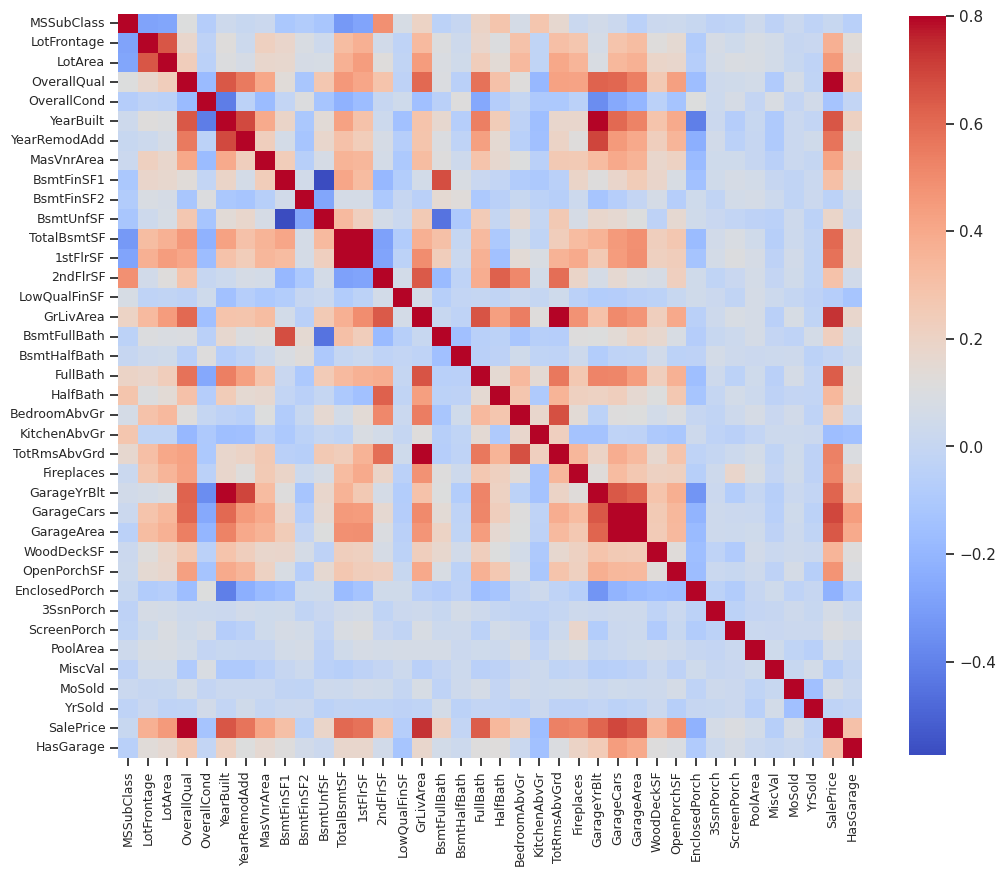

In [ ]:
correlation_matrix = train.corr(method='spearman', numeric_only=True) # spearman to account for non-linearity

fig, ax = plt.subplots(figsize=(12,12))
sns.heatmap(correlation_matrix, vmax=0.8, square=True, cbar_kws={'shrink': 0.8}, cmap='coolwarm')

ax.tick_params(axis='both', labelsize=9)
plt.show()

In [ ]:
sns.pairplot()

## Look for Outliers

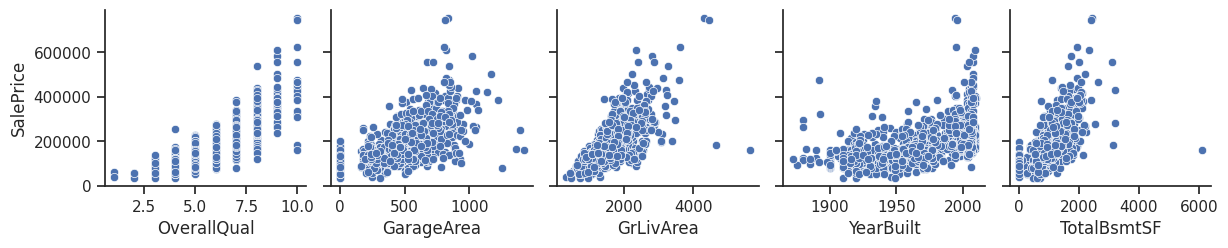

In [11]:
# see outliers in garage area, GrLivArea, and TotalBsmtSF
correlated_cols = ['OverallQual', 'GarageArea', 'GrLivArea', 'YearBuilt', 'TotalBsmtSF']
sns.pairplot(data=train, y_vars='SalePrice', x_vars=correlated_cols)
plt.show()